# IDX — 02 Preprocessing

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## Load & filter

restrict to `PropertyType == "Residential"` and
`PropertySubType == "SingleFamilyResidence"`.

In [2]:
def find_data_dir():
    for cand in [Path("."), Path(".."), Path("../..")]:
        if sorted(cand.glob("CRMLSSold*.csv")):
            return cand
    raise FileNotFoundError("Could not locate CRMLSSold*.csv files.")

DATA_DIR = find_data_dir()
files = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

mask = (raw["PropertyType"] == "Residential") & (raw["PropertySubType"] == "SingleFamilyResidence")
df = raw.loc[mask].copy()
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["CloseMonth"] = df["CloseDate"].dt.to_period("M").astype(str)
print(f"{len(files)} files, {len(raw):,} rows total, {len(df):,} single-family rows")
df["CloseMonth"].value_counts().sort_index()

6 files, 124,404 rows total, 61,727 single-family rows


CloseMonth
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Name: count, dtype: int64

In [3]:
TARGET = "ClosePrice"

# numeric features
NUM = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
       "YearBuilt", "GarageSpaces", "ParkingTotal", "Stories", "AssociationFee",
       "DaysOnMarket", "Latitude", "Longitude", "MainLevelBedrooms"]

# boolean amenity flags -> 0/1
BOOL = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN"]

# high-cardinality location categoricals -> smoothed target encoding
CAT_HI = ["PostalCode", "City", "MLSAreaMajor", "HighSchoolDistrict", "CountyOrParish"]

# low-cardinality categorical -> one-hot
CAT_LO = ["Levels"]

keep = [TARGET, "CloseDate", "CloseMonth"] + NUM + BOOL + CAT_HI + CAT_LO
d = df[keep].copy()
d.head(3)

,ClosePrice,CloseDate,CloseMonth,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,ParkingTotal,Stories,AssociationFee,DaysOnMarket,Latitude,Longitude,MainLevelBedrooms,ViewYN,PoolPrivateYN,AttachedGarageYN,FireplaceYN,NewConstructionYN,PostalCode,City,MLSAreaMajor,HighSchoolDistrict,CountyOrParish,Levels
0,1998000.0,2025-12-31,2025-12,2045.0,4.0,2.0,10080.0,1968.0,3.0,3.0,1.0,975.0,0,37.871927,-122.029871,NaN,NaN,False,True,True,False,94596,Walnut Creek,NaN,San Ramon Valley,Contra Costa,One
2,2214421.0,2025-12-31,2025-12,3050.0,4.0,4.0,34745.0,1957.0,3.0,7.0,2.0,NaN,0,34.150680,-118.580650,NaN,True,False,True,True,False,91364,Woodland Hills,NaN,NaN,Los Angeles,Two
3,1200000.0,2025-12-31,2025-12,1594.0,4.0,2.0,6600.0,1978.0,2.0,2.0,NaN,NaN,0,37.306405,-121.835428,NaN,False,NaN,True,True,False,95121,San Jose,699 - Not Defined,Other,Santa Clara,NaN


## Missing values

In [4]:
miss = d.isna().mean().mul(100).round(1).sort_values(ascending=False)
miss[miss > 0].to_frame("% missing")

,% missing
MainLevelBedrooms,39.0
AssociationFee,28.5
HighSchoolDistrict,26.9
MLSAreaMajor,14.1
AttachedGarageYN,12.2
Stories,10.5
ViewYN,8.6
PoolPrivateYN,7.8
NewConstructionYN,7.6
Levels,7.5


In [5]:
n0 = len(d)
d = d[d["ClosePrice"].between(50_000, 30_000_000)]
d = d[d["LivingArea"].between(200, 20_000)]
d = d[d["BedroomsTotal"].between(0, 12) & d["BathroomsTotalInteger"].between(1, 12)]
d = d[d["CloseDate"].notna()]
print(f"{n0:,} -> {len(d):,} rows ({n0 - len(d):,} dropped, {(n0-len(d))/n0:.2%})")

61,727 -> 61,603 rows (124 dropped, 0.20%)


### Invalid values → NaN

Non-essential fields with impossible values are set to NaN and later imputed
rather than dropping the whole row.

In [6]:
d.loc[~d["YearBuilt"].between(1850, 2026), "YearBuilt"] = np.nan
d.loc[~d["Latitude"].between(32, 42.5), "Latitude"] = np.nan        # CA bounds
d.loc[~d["Longitude"].between(-125, -113.5), "Longitude"] = np.nan
d.loc[d["LotSizeSquareFeet"] <= 0, "LotSizeSquareFeet"] = np.nan
d["DaysOnMarket"] = d["DaysOnMarket"].clip(lower=0)   # a few negative DOM entries

## Encoding categorical


In [7]:
# booleans -> 0/1
for c in BOOL:
    d[c] = d[c].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int)

# HOA
d["HasHOA"] = (d["AssociationFee"].fillna(0) > 0).astype(int)
d["AssociationFee"] = d["AssociationFee"].fillna(0)

# Levels -> primary value, rare/missing grouped
d["Levels"] = d["Levels"].fillna("Missing").str.split(",").str[0]
d.loc[~d["Levels"].isin(["One", "Two", "ThreeOrMore", "MultiSplit", "Missing"]), "Levels"] = "Other"
d["Levels"].value_counts()

Levels
One            35114
Two            19678
Missing         4615
ThreeOrMore     1258
MultiSplit       938
Name: count, dtype: int64

In [8]:
def target_encode(tr, te, col, y_log, m=20):
    """Smoothed target (mean log-price) encoding, fit on train only."""
    key = tr[col].fillna("__NA__")
    stats = y_log.groupby(key).agg(["mean", "count"])
    glob = y_log.mean()
    enc = (stats["count"] * stats["mean"] + m * glob) / (stats["count"] + m)
    return (tr[col].fillna("__NA__").map(enc).fillna(glob),
            te[col].fillna("__NA__").map(enc).fillna(glob))

## Normalization

In [9]:
LOG1P = ["LivingArea", "LotSizeSquareFeet", "AssociationFee", "DaysOnMarket"]
NUMS_ALL = NUM + ["HasHOA"] + BOOL   # all numeric model inputs pre-encoding

def build_xy(tr, te):
    """Fit imputation/encoding/scaling on `tr` only; transform both."""
    tr, te = tr.copy(), te.copy()
    ylog_tr, ylog_te = np.log(tr["ClosePrice"]), np.log(te["ClosePrice"])

    for c in LOG1P:
        tr[c], te[c] = np.log1p(tr[c]), np.log1p(te[c])

    med = tr[NUMS_ALL].median()
    tr[NUMS_ALL] = tr[NUMS_ALL].fillna(med)
    te[NUMS_ALL] = te[NUMS_ALL].fillna(med)

    feats = list(NUMS_ALL)
    for c in CAT_HI:
        tr[c + "_te"], te[c + "_te"] = target_encode(tr, te, c, ylog_tr)
        feats.append(c + "_te")

    lv_tr = pd.get_dummies(tr["Levels"], prefix="Levels").astype(int)
    lv_te = pd.get_dummies(te["Levels"], prefix="Levels").reindex(columns=lv_tr.columns, fill_value=0).astype(int)

    Xtr = pd.concat([tr[feats], lv_tr], axis=1)
    Xte = pd.concat([te[feats], lv_te], axis=1)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = pd.DataFrame(scaler.transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_s = pd.DataFrame(scaler.transform(Xte), columns=Xte.columns, index=Xte.index)
    return Xtr_s, Xte_s, ylog_tr, ylog_te

## Train/test split

In [10]:
MONTHS = sorted(d["CloseMonth"].unique())
TEST_MONTH = MONTHS[-1]
test = d[d["CloseMonth"] == TEST_MONTH]
print(f"Test month: {TEST_MONTH}  ({len(test):,} rows)")

rows = []
for X in range(1, len(MONTHS)):
    train_months = MONTHS[-1 - X:-1]
    train = d[d["CloseMonth"].isin(train_months)]
    Xtr, Xte, ytr, yte = build_xy(train, test)
    model = LinearRegression().fit(Xtr, ytr)
    pred_log = model.predict(Xte)
    pred = np.exp(pred_log)
    price = test["ClosePrice"]
    ape = np.abs(pred - price) / price
    rows.append({
        "X (months)": X,
        "train window": f"{train_months[0]} .. {train_months[-1]}",
        "n_train": len(train),
        "MAE ($)": mean_absolute_error(price, pred),
        "MedAPE (%)": np.median(ape) * 100,
        "MAPE (%)": ape.mean() * 100,
        "R2 (log price)": r2_score(yte, pred_log),
    })

results = pd.DataFrame(rows)
results.round(3)

Test month: 2026-05  (11,996 rows)


,X (months),train window,n_train,MAE ($),MedAPE (%),MAPE (%),R2 (log price)
0,1,2026-04 .. 2026-04,12009,279319.697,14.892,20.612,0.838
1,2,2026-03 .. 2026-04,23166,268609.786,14.130,19.683,0.851
2,3,2026-02 .. 2026-04,31701,263779.679,13.702,19.167,0.858
3,4,2026-01 .. 2026-04,39168,262507.726,13.552,18.892,0.861
4,5,2025-12 .. 2026-04,49607,262259.759,13.286,18.614,0.864


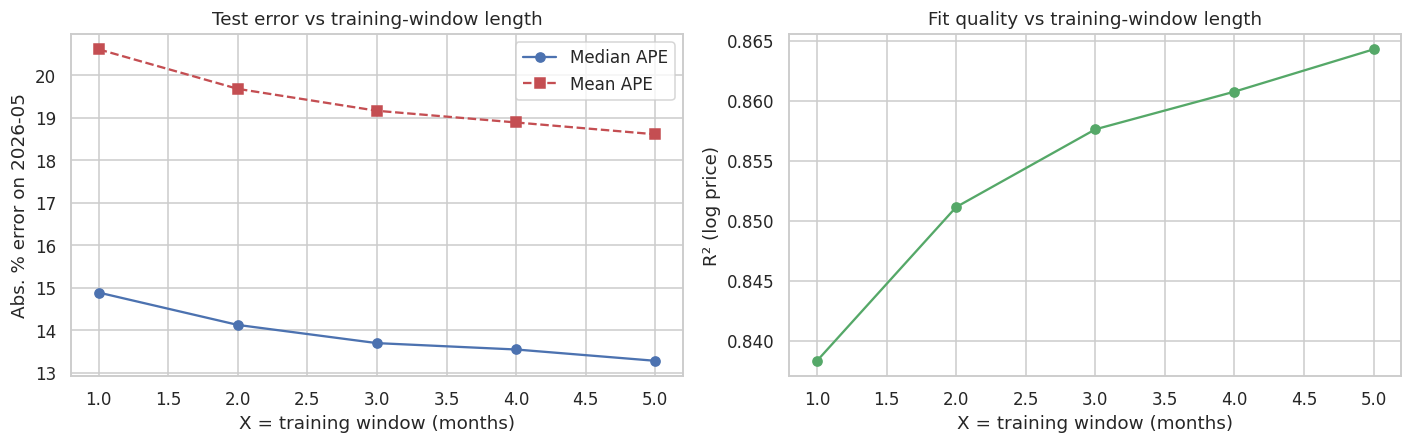

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(results["X (months)"], results["MedAPE (%)"], "o-", color="#4C72B0", label="Median APE")
axes[0].plot(results["X (months)"], results["MAPE (%)"], "s--", color="#C44E52", label="Mean APE")
axes[0].set_xlabel("X = training window (months)")
axes[0].set_ylabel("Abs. % error on 2026-05")
axes[0].set_title("Test error vs training-window length")
axes[0].legend()

axes[1].plot(results["X (months)"], results["R2 (log price)"], "o-", color="#55A868")
axes[1].set_xlabel("X = training window (months)")
axes[1].set_ylabel("R² (log price)")
axes[1].set_title("Fit quality vs training-window length")
fig.tight_layout()
plt.show()

In [12]:
BEST_X = int(results.loc[results["MedAPE (%)"].idxmin(), "X (months)"])
print(f"Best training window: X = {BEST_X} months "
      f"({results.loc[results['MedAPE (%)'].idxmin(), 'train window']})")

Best training window: X = 5 months (2025-12 .. 2026-04)


## Final split & deliverable files

In [13]:
train_months = MONTHS[-1 - BEST_X:-1]
train = d[d["CloseMonth"].isin(train_months)]

d_out = d.copy()
d_out["split"] = np.select(
    [d_out["CloseMonth"] == TEST_MONTH, d_out["CloseMonth"].isin(train_months)],
    ["test", "train"], default="unused")
d_out.to_csv("sfr_cleaned.csv", index=False)

Xtr, Xte, ytr, yte = build_xy(train, test)
Xtr.assign(log_ClosePrice=ytr).to_csv("sfr_train_model_ready.csv", index=False)
Xte.assign(log_ClosePrice=yte).to_csv("sfr_test_model_ready.csv", index=False)

print(f"sfr_cleaned.csv            {d_out.shape[0]:,} rows x {d_out.shape[1]} cols")
print(f"sfr_train_model_ready.csv  {Xtr.shape[0]:,} rows x {Xtr.shape[1]+1} cols")
print(f"sfr_test_model_ready.csv   {Xte.shape[0]:,} rows x {Xte.shape[1]+1} cols")
d_out["split"].value_counts()

sfr_cleaned.csv            61,603 rows x 29 cols
sfr_train_model_ready.csv  49,607 rows x 30 cols
sfr_test_model_ready.csv   11,996 rows x 30 cols


split
train    49607
test     11996
Name: count, dtype: int64